In [4]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from simulator import SimulationConfig, SimpleLOBSimulator


def run_batch(queue_ahead, n_runs=1000):

    results = []

    for seed in range(n_runs):

        config = SimulationConfig(

            seed=seed,

            initial_queue_ahead=queue_ahead,

            n_steps=80,

            post_fill_horizon=20,

            market_sell_rate=0.25,

            cancellation_rate=0.05,

            limit_replenish_rate=0.2,

        )

        sim = SimpleLOBSimulator(config)

        sim.run()

        results.append(sim.summarize())

    return pd.DataFrame(results)


queue_values = [2, 5, 10, 20, 40, 80]
summary = []

for q in queue_values:
    df = run_batch(q, n_runs=500)
    summary.append({
        "queue_ahead": q,
        "fill_probability": df["filled"].mean(),
        "avg_net_execution_value": df["net_execution_value"].mean(),
        "avg_adverse_drift": df["adverse_drift"].mean(),
    })

summary_df = pd.DataFrame(summary)
summary_df

,queue_ahead,fill_probability,avg_net_execution_value,avg_adverse_drift
0,2,1.000,-0.003818,0.013818
1,5,1.000,-0.008016,0.018016
2,10,1.000,-0.014770,0.024770
3,20,0.824,-0.019881,0.029881
4,40,0.002,0.010000,0.000000
5,80,0.000,NaN,NaN


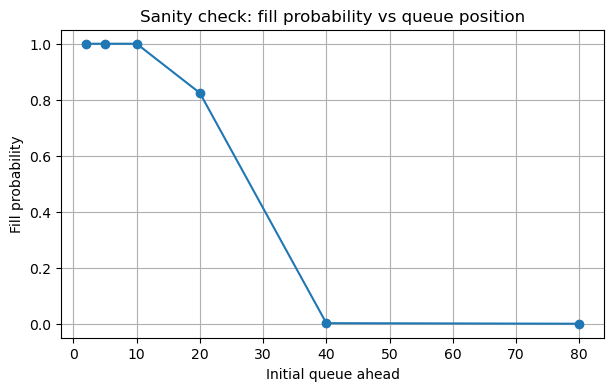

In [5]:
plt.figure(figsize=(7, 4))

plt.plot(summary_df["queue_ahead"], summary_df["fill_probability"], marker="o")

plt.xlabel("Initial queue ahead")

plt.ylabel("Fill probability")

plt.title("Sanity check: fill probability vs queue position")

plt.grid(True)

plt.show()

In [6]:
def run_imbalance_batch(initial_imbalance, n_runs=1000):
    results = []
    
    bid_depth = 100 * (1 + initial_imbalance)
    ask_depth = 100 * (1 - initial_imbalance)
    
    for seed in range(n_runs):
        config = SimulationConfig(
            seed=seed,
            initial_queue_ahead=20,
            n_steps=80,
            post_fill_horizon=20,
            market_sell_rate=0.25,
            cancellation_rate=0.05,
            limit_replenish_rate=0.2,
            initial_bid_depth=bid_depth,
            initial_ask_depth=ask_depth,
            volatility=0.01,
            imbalance_price_impact=0.01,
        )
        sim = SimpleLOBSimulator(config)
        sim.run()
        results.append(sim.summarize())
        
    return pd.DataFrame(results)


imbalance_values = [-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8]

imbalance_summary = []

for imb in imbalance_values:
    df = run_imbalance_batch(imb, n_runs=1000)
    filled_df = df[df["filled"] == True]
    
    imbalance_summary.append({
        "initial_imbalance": imb,
        "fill_probability": df["filled"].mean(),
        "avg_post_fill_drift": filled_df["post_fill_drift"].mean(),
        "avg_adverse_drift": filled_df["adverse_drift"].mean(),
        "avg_net_execution_value": filled_df["net_execution_value"].mean(),
        "n_filled": len(filled_df),
    })

imbalance_summary_df = pd.DataFrame(imbalance_summary)
imbalance_summary_df

,initial_imbalance,fill_probability,avg_post_fill_drift,avg_adverse_drift,avg_net_execution_value,n_filled
0,-0.8,0.817,-0.636618,0.636618,-0.626618,817
1,-0.6,0.817,-0.486293,0.486293,-0.476293,817
2,-0.4,0.817,-0.335950,0.335950,-0.325950,817
3,-0.2,0.817,-0.185608,0.185963,-0.175963,817
4,0.0,0.817,-0.035266,0.055790,-0.045790,817
5,0.2,0.817,0.115077,0.004121,0.005879,817
6,0.4,0.817,0.265419,0.000051,0.009949,817
7,0.6,0.817,0.415761,0.000000,0.010000,817
8,0.8,0.817,0.566104,0.000000,0.010000,817


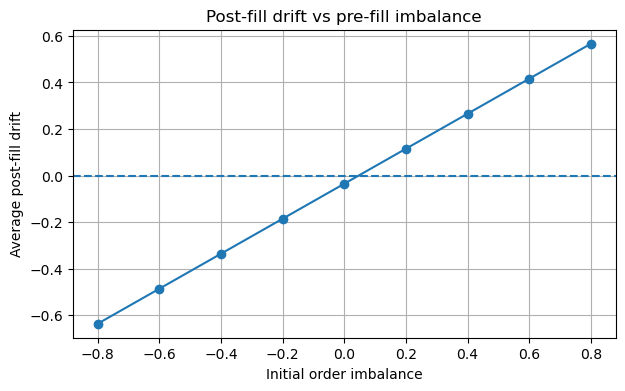

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(
    imbalance_summary_df["initial_imbalance"],
    imbalance_summary_df["avg_post_fill_drift"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Initial order imbalance")
plt.ylabel("Average post-fill drift")
plt.title("Post-fill drift vs pre-fill imbalance")
plt.grid(True)
plt.show()


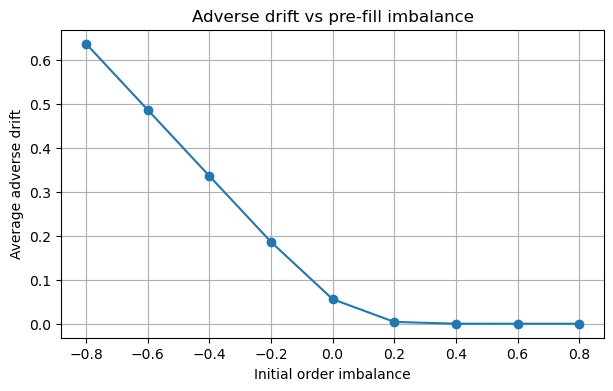

In [8]:
plt.figure(figsize=(7, 4))

plt.plot(

    imbalance_summary_df["initial_imbalance"],

    imbalance_summary_df["avg_adverse_drift"],

    marker="o"

)

plt.xlabel("Initial order imbalance")

plt.ylabel("Average adverse drift")

plt.title("Adverse drift vs pre-fill imbalance")

plt.grid(True)

plt.show()


In [9]:
def run_regime_batch(initial_imbalance, volatility, n_runs=1000):
    results = []

    bid_depth = 100 * (1 + initial_imbalance)
    ask_depth = 100 * (1 - initial_imbalance)

    for seed in range(n_runs):
        config = SimulationConfig(
            seed=seed,
            initial_queue_ahead=20,
            n_steps=80,
            post_fill_horizon=20,
            market_sell_rate=0.25,
            cancellation_rate=0.05,
            limit_replenish_rate=0.2,
            initial_bid_depth=bid_depth,
            initial_ask_depth=ask_depth,
            volatility=volatility,
            imbalance_price_impact=0.01,
        )
        sim = SimpleLOBSimulator(config)
        sim.run()
        results.append(sim.summarize())

    return pd.DataFrame(results)


imbalance_values = [-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8]
volatility_values = [0.002, 0.005, 0.01, 0.02, 0.04]

heatmap_rows = []

for vol in volatility_values:
    for imb in imbalance_values:
        df = run_regime_batch(imb, vol, n_runs=1000)
        filled_df = df[df["filled"] == True]

        heatmap_rows.append({
            "volatility": vol,
            "initial_imbalance": imb,
            "fill_probability": df["filled"].mean(),
            "avg_post_fill_drift": filled_df["post_fill_drift"].mean(),
            "avg_adverse_drift": filled_df["adverse_drift"].mean(),
            "avg_net_execution_value": filled_df["net_execution_value"].mean(),
            "bad_fill_ratio": (filled_df["net_execution_value"] < 0).mean(),
            "n_filled": len(filled_df),
        })

heatmap_df = pd.DataFrame(heatmap_rows)
heatmap_df.head()

,volatility,initial_imbalance,fill_probability,avg_post_fill_drift,avg_adverse_drift,avg_net_execution_value,bad_fill_ratio,n_filled
0,0.002,-0.8,0.817,-0.637965,0.637965,-0.627965,1.000000,817
1,0.002,-0.6,0.817,-0.487640,0.487640,-0.477640,1.000000,817
2,0.002,-0.4,0.817,-0.337298,0.337298,-0.327298,1.000000,817
3,0.002,-0.2,0.817,-0.186956,0.186956,-0.176956,1.000000,817
4,0.002,0.0,0.817,-0.036613,0.036944,-0.026944,0.902081,817


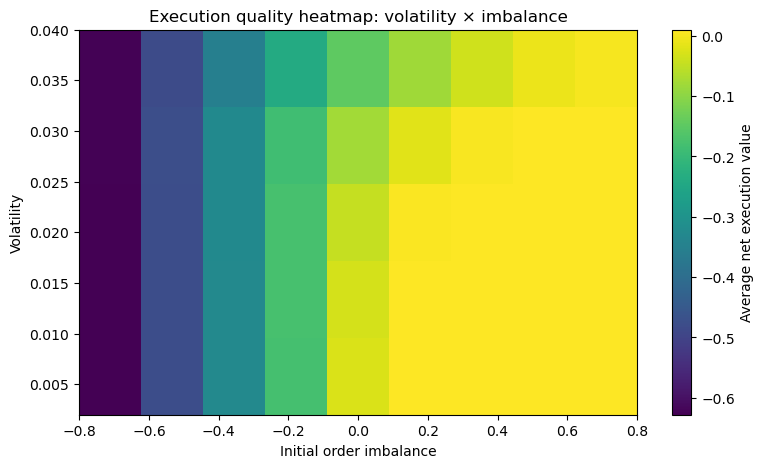

In [10]:
pivot_eq = heatmap_df.pivot(
    index="volatility",
    columns="initial_imbalance",
    values="avg_net_execution_value"
)

plt.figure(figsize=(9, 5))
plt.imshow(
    pivot_eq,
    aspect="auto",
    origin="lower",
    extent=[
        min(imbalance_values),
        max(imbalance_values),
        min(volatility_values),
        max(volatility_values),
    ],
)
plt.colorbar(label="Average net execution value")
plt.xlabel("Initial order imbalance")
plt.ylabel("Volatility")
plt.title("Execution quality heatmap: volatility × imbalance")
plt.show()

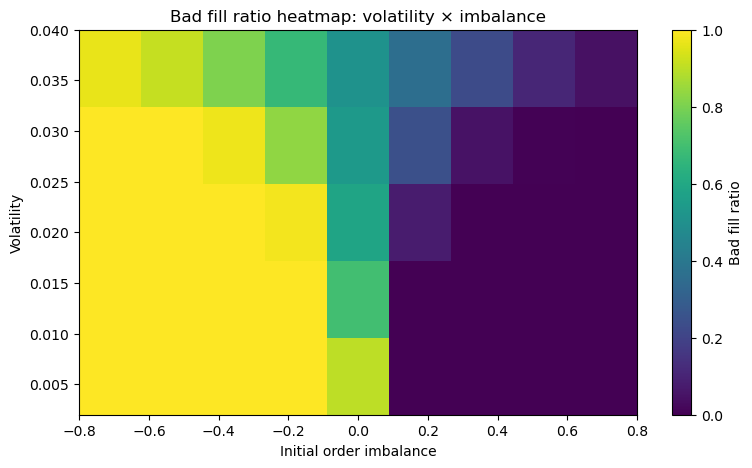

In [11]:
pivot_bad = heatmap_df.pivot(
    index="volatility",
    columns="initial_imbalance",
    values="bad_fill_ratio"
)

plt.figure(figsize=(9, 5))
plt.imshow(
    pivot_bad,
    aspect="auto",
    origin="lower",
    extent=[
        min(imbalance_values),
        max(imbalance_values),
        min(volatility_values),
        max(volatility_values),
    ],
)
plt.colorbar(label="Bad fill ratio")
plt.xlabel("Initial order imbalance")
plt.ylabel("Volatility")
plt.title("Bad fill ratio heatmap: volatility × imbalance")
plt.show()

In [12]:
 ##The execution-quality heatmap shows that adverse-selection-adjusted execution value is primarily shaped by the pre-fill imbalance regime. For passive buy orders, negative imbalance leads to strongly negative net execution value, while positive imbalance preserves or improves execution quality. In this v0.1 simulator, volatility does not materially change the conditional mean because it enters as symmetric noise; its effect should be evaluated through bad-fill frequency and dispersion. 


In [13]:
def sample_initial_imbalance(rng):
    # uniform regime sampling for v0.1 experiment
    return rng.choice([-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8])


def run_strategy_comparison(n_runs=5000, volatility=0.02):
    rng = np.random.default_rng(123)

    always_results = []
    filtered_results = []

    for seed in range(n_runs):
        initial_imbalance = sample_initial_imbalance(rng)

        bid_depth = 100 * (1 + initial_imbalance)
        ask_depth = 100 * (1 - initial_imbalance)

        # Always-passive strategy
        config = SimulationConfig(
            seed=seed,
            initial_queue_ahead=20,
            n_steps=80,
            post_fill_horizon=20,
            market_sell_rate=0.25,
            cancellation_rate=0.05,
            limit_replenish_rate=0.2,
            initial_bid_depth=bid_depth,
            initial_ask_depth=ask_depth,
            volatility=volatility,
            imbalance_price_impact=0.01,
        )

        sim = SimpleLOBSimulator(config)
        sim.run()
        result = sim.summarize()
        result["strategy"] = "always_passive"
        result["initial_imbalance"] = initial_imbalance
        result["traded"] = True
        always_results.append(result)

        # Filtered-passive strategy
        if initial_imbalance >= 0:
            config = SimulationConfig(
                seed=seed + 100000,
                initial_queue_ahead=20,
                n_steps=80,
                post_fill_horizon=20,
                market_sell_rate=0.25,
                cancellation_rate=0.05,
                limit_replenish_rate=0.2,
                initial_bid_depth=bid_depth,
                initial_ask_depth=ask_depth,
                volatility=volatility,
                imbalance_price_impact=0.01,
            )

            sim = SimpleLOBSimulator(config)
            sim.run()
            result = sim.summarize()
            result["strategy"] = "filtered_passive"
            result["initial_imbalance"] = initial_imbalance
            result["traded"] = True
            filtered_results.append(result)
        else:
            # skipped trade
            filtered_results.append({
                "strategy": "filtered_passive",
                "initial_imbalance": initial_imbalance,
                "traded": False,
                "filled": False,
                "net_execution_value": np.nan,
                "adverse_drift": np.nan,
                "post_fill_drift": np.nan,
                "spread_capture": np.nan,
            })

    return pd.DataFrame(always_results), pd.DataFrame(filtered_results)


always_df, filtered_df = run_strategy_comparison(n_runs=5000, volatility=0.02)

In [14]:
def summarize_strategy(df):
    traded_df = df[df["traded"] == True]
    filled_df = traded_df[traded_df["filled"] == True]

    return {
        "trade_rate": df["traded"].mean(),
        "fill_rate_given_traded": traded_df["filled"].mean(),
        "overall_fill_rate": df["filled"].mean(),
        "avg_net_execution_value_given_fill": filled_df["net_execution_value"].mean(),
        "avg_adverse_drift_given_fill": filled_df["adverse_drift"].mean(),
        "bad_fill_ratio_given_fill": (filled_df["net_execution_value"] < 0).mean(),
        "n_traded": len(traded_df),
        "n_filled": len(filled_df),
    }


comparison = pd.DataFrame([
    {"strategy": "always_passive", **summarize_strategy(always_df)},
    {"strategy": "filtered_passive", **summarize_strategy(filtered_df)},
])

comparison

,strategy,trade_rate,fill_rate_given_traded,overall_fill_rate,avg_net_execution_value_given_fill,avg_adverse_drift_given_fill,bad_fill_ratio_given_fill,n_traded,n_filled
0,always_passive,1.0000,0.820600,0.8206,-0.191455,0.201455,0.524007,5000,4103
1,filtered_passive,0.5508,0.826071,0.4550,-0.014694,0.024694,0.181099,2754,2275


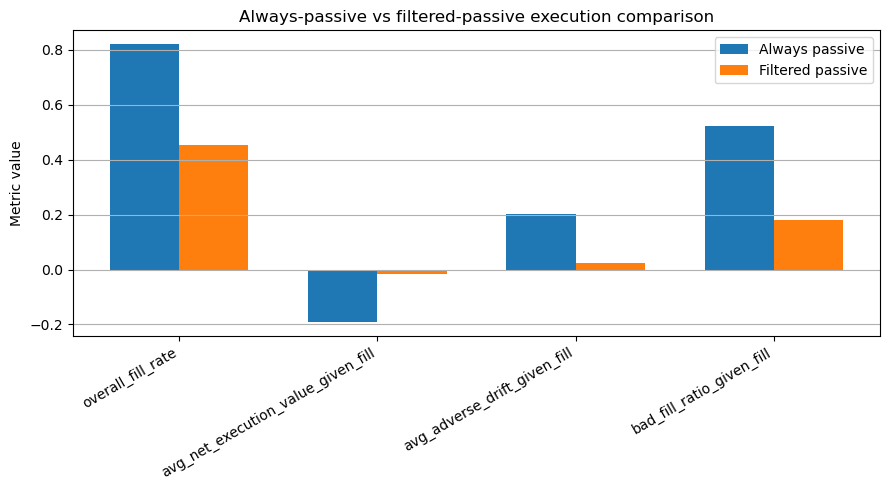

In [15]:
metrics_to_plot = [
    "overall_fill_rate",
    "avg_net_execution_value_given_fill",
    "avg_adverse_drift_given_fill",
    "bad_fill_ratio_given_fill",
]

plot_df = comparison.set_index("strategy")[metrics_to_plot].T

plt.figure(figsize=(9, 5))
x = np.arange(len(metrics_to_plot))
width = 0.35

plt.bar(x - width/2, plot_df["always_passive"], width, label="Always passive")
plt.bar(x + width/2, plot_df["filtered_passive"], width, label="Filtered passive")

plt.xticks(x, metrics_to_plot, rotation=30, ha="right")
plt.ylabel("Metric value")
plt.title("Always-passive vs filtered-passive execution comparison")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()